In [6]:
import random
import json
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from faker import Faker


fake = Faker('es_MX')
random.seed(42)
np.random.seed(42)

N = 5000

CATEGORIAS = ['Electrónica', 'Ropa', 'Hogar', 'Deportes',
              'Juguetes', 'Alimentos', 'Belleza', 'Libros']

METODOS_PAGO = ['Tarjeta de crédito', 'Tarjeta de débito',
                'PayPal', 'Transferencia', 'Efectivo']

PRODUCTOS = {
    'Electrónica':  ['Laptop Core i7 16GB', 'Smartphone 5G 256GB',
                     'Tablet 10 pulgadas', 'Auriculares Bluetooth'],
    'Ropa':         ['Playera algodón premium', 'Jeans slim fit',
                     'Vestido casual verano', 'Sudadera con capucha'],
    'Hogar':        ['Silla ergonómica oficina', 'Lámpara LED escritorio',
                     'Cafetera programable', 'Set de sábanas 400 hilos'],
    'Deportes':     ['Tenis running profesional', 'Mancuernas ajustables',
                     'Colchoneta yoga antideslizante', 'Bicicleta estática'],
    'Juguetes':     ['Set Lego arquitectura', 'Muñeca articulada deluxe',
                     'Auto control remoto', 'Juego de mesa familiar'],
    'Alimentos':    ['Pack proteína whey 1kg', 'Café molido orgánico 500g',
                     'Snack saludable mixto', 'Suplemento vitamínico'],
    'Belleza':      ['Crema hidratante FPS 50', 'Perfume floral 100ml',
                     'Kit maquillaje profesional', 'Shampoo sin sulfatos'],
    'Libros':       ['Python para Ciencia de Datos', 'Marketing Digital 2024',
                     'Finanzas personales', 'Novela bestseller año']
}

COMENTARIOS = [
    'Excelente producto, llegó antes de lo esperado y en perfectas condiciones.',
    'Muy buena relación calidad-precio, lo recomiendo ampliamente.',
    'El producto es tal y como se describe, estoy muy satisfecho.',
    'Entrega rápida, el empaque estaba en buen estado.',
    'El artículo es de buena calidad aunque el envío tardó un poco.',
    'No cumplió del todo mis expectativas pero sirve para lo básico.',
    'Increíble producto, superó todas mis expectativas.',
    'Buen precio pero la calidad podría mejorar.',
    'Segunda compra, siempre quedo satisfecho con este vendedor.',
    'Producto auténtico y de calidad, envío rápido y seguro.'
]

fecha_inicio = datetime(2026, 1, 1)
fechas = [fecha_inicio + timedelta(days=random.randint(0, 364)) for _ in range(N)]

registros = []
for i in range(N):
    categoria = random.choice(CATEGORIAS)
    precio    = round(random.uniform(50, 3000), 2)
    cantidad  = random.randint(1, 20)
    descuento = round(random.uniform(0, 0.40), 2)
    total     = round(precio * cantidad * (1 - descuento), 2)

    direccion = {
        'calle':  fake.street_address(),
        'ciudad': fake.city(),
        'estado': fake.state(),
        'cp':     fake.postcode()
    }

    registros.append({
        'precio_unitario':    precio,
        'cantidad':           cantidad,
        'total_venta':        total,
        'descuento_pct':      descuento,
        'categoria':          categoria,
        'metodo_pago':        random.choice(METODOS_PAGO),
        'fecha_venta':        fechas[i].strftime('%Y-%m-%d'),
        'direccion_envio':    json.dumps(direccion, ensure_ascii=False),
        'comentario_cliente': random.choice(COMENTARIOS),
        'nombre_producto':    random.choice(PRODUCTOS[categoria])
    })

df = pd.DataFrame(registros)
print(f'Dataset creado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()


Dataset creado: 5000 filas × 10 columnas


,precio_unitario,cantidad,total_venta,descuento_pct,categoria,metodo_pago,fecha_venta,direccion_envio,comentario_cliente,nombre_producto
0,2563.02,6,14916.78,0.03,Libros,Transferencia,2026-11-24,"{""calle"": ""Privada Durango 782 Edif. 646 , Dep...",No cumplió del todo mis expectativas pero sirv...,Marketing Digital 2024
1,2911.93,2,4659.09,0.20,Alimentos,Efectivo,2026-02-27,"{""calle"": ""Continuación Uzbekistán 764 Interio...","Increíble producto, superó todas mis expectati...",Suplemento vitamínico
2,282.55,15,2882.01,0.32,Deportes,Transferencia,2026-01-13,"{""calle"": ""Circuito Tamaulipas 976 190"", ""ciud...","Muy buena relación calidad-precio, lo recomien...",Bicicleta estática
3,982.38,16,11002.66,0.30,Libros,Tarjeta de crédito,2026-05-21,"{""calle"": ""Circuito Norte Marín 382 Interior 7...","Muy buena relación calidad-precio, lo recomien...",Novela bestseller año
4,155.70,18,2802.60,0.00,Belleza,Tarjeta de crédito,2026-05-06,"{""calle"": ""Andador Barela 451 456"", ""ciudad"": ...","Producto auténtico y de calidad, envío rápido ...",Kit maquillaje profesional


In [5]:
from pymongo import MongoClient
from pymongo.errors import ConnectionFailure

try:
 cliente = MongoClient('mongodb://localhost:27017/',
 serverSelectionTimeoutMS=5000)
 cliente.admin.command('ping') # Verificar conexión
 print('Conexión a MongoDB exitosa')
except ConnectionFailure as e:
 print(f' Error de conexión: {e}')

db = cliente['todo_ventas_db']
coleccion = db['ventas_2026']

coleccion.drop()
print(f'Colección limpiada. Cargando {len(registros)} documentos...')

tamano_lote = 500
for i in range(0, len(registros), tamano_lote):
 lote = registros[i : i + tamano_lote]
 coleccion.insert_many(lote)
print(f'✅ {coleccion.count_documents({})} documentos insertados en MongoDB')

Conexión a MongoDB exitosa
Colección limpiada. Cargando 5000 documentos...
✅ 5000 documentos insertados en MongoDB


In [8]:
import pandas as pd
import numpy as np

cursor = coleccion.find({}, {'_id': 0})
df = pd.DataFrame(list(cursor))

df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])
df['precio_unitario'] = df['precio_unitario'].astype(float)
df['total_venta'] = df['total_venta'].astype(float)
df['descuento_pct'] = df['descuento_pct'].astype(float)
df['cantidad'] = df['cantidad'].astype(int)
print(f'DataFrame cargado: {df.shape}')
df.head(3)

DataFrame cargado: (5000, 10)


,precio_unitario,cantidad,total_venta,descuento_pct,categoria,metodo_pago,fecha_venta,direccion_envio,comentario_cliente,nombre_producto
0,2563.02,6,14916.78,0.03,Libros,Transferencia,2026-11-24,"{""calle"": ""Cerrada Tamaulipas 305 211"", ""ciuda...",No cumplió del todo mis expectativas pero sirv...,Marketing Digital 2024
1,2911.93,2,4659.09,0.20,Alimentos,Efectivo,2026-02-27,"{""calle"": ""Corredor Eslovenia 553 Interior 688...","Increíble producto, superó todas mis expectati...",Suplemento vitamínico
2,282.55,15,2882.01,0.32,Deportes,Transferencia,2026-01-13,"{""calle"": ""Viaducto Carreón 109 Edif. 170 , De...","Muy buena relación calidad-precio, lo recomien...",Bicicleta estática


In [9]:

print('Tipos de datos:')
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())
print(f'\nDuplicados: {df.duplicated().sum()}')

Tipos de datos:
precio_unitario              float64
cantidad                       int64
total_venta                  float64
descuento_pct                float64
categoria                        str
metodo_pago                      str
fecha_venta           datetime64[us]
direccion_envio                  str
comentario_cliente               str
nombre_producto                  str
dtype: object

Valores nulos:
precio_unitario       0
cantidad              0
total_venta           0
descuento_pct         0
categoria             0
metodo_pago           0
fecha_venta           0
direccion_envio       0
comentario_cliente    0
nombre_producto       0
dtype: int64

Duplicados: 0


In [10]:
columnas_num = ['precio_unitario', 'cantidad', 'total_venta', 'descuento_pct']

medias   = df[columnas_num].mean().round(2)
medianas = df[columnas_num].median().round(2)
modas    = df[columnas_num].mode().iloc[0].round(2)


resumen = pd.DataFrame({
    'Media':   medias,
    'Mediana': medianas,
    'Moda':    modas
})

print('Resumen estadístico:')
print(resumen)

Resumen estadístico:
                    Media  Mediana    Moda
precio_unitario   1512.78  1505.41   74.84
cantidad            10.59    11.00   14.00
total_venta      12703.96  9702.98  492.44
descuento_pct        0.20     0.20    0.32


In [11]:
# ventas por categoria
print('Ventas por categoría:')
print(df['categoria'].value_counts())

# metodos de pago mas usados
print('\nMétodos de pago:')
print(df['metodo_pago'].value_counts())

Ventas por categoría:
categoria
Electrónica    661
Ropa           659
Belleza        656
Deportes       653
Libros         628
Hogar          615
Juguetes       566
Alimentos      562
Name: count, dtype: int64

Métodos de pago:
metodo_pago
Tarjeta de crédito    1021
Transferencia         1013
Efectivo              1007
Tarjeta de débito      980
PayPal                 979
Name: count, dtype: int64


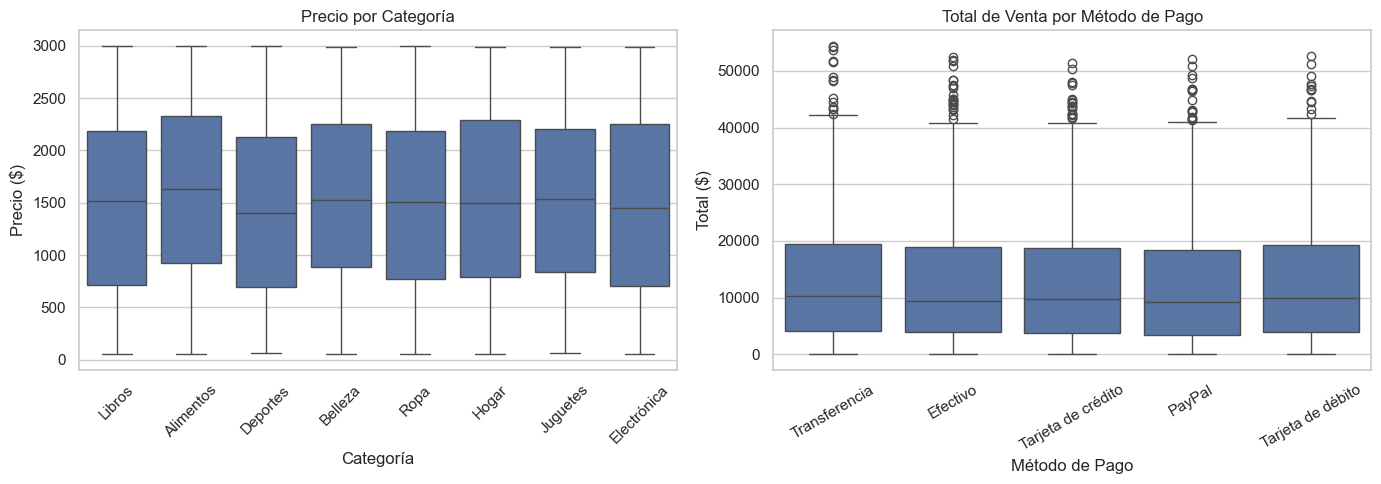

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot del precio por categoría
sns.boxplot(data=df, x='categoria', y='precio_unitario', ax=axes[0])
axes[0].set_title('Precio por Categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Precio ($)')
axes[0].tick_params(axis='x', rotation=45)

# Box plot del total de venta por método de pago
sns.boxplot(data=df, x='metodo_pago', y='total_venta', ax=axes[1])
axes[1].set_title('Total de Venta por Método de Pago')
axes[1].set_xlabel('Método de Pago')
axes[1].set_ylabel('Total ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('boxplot.png')
plt.show()


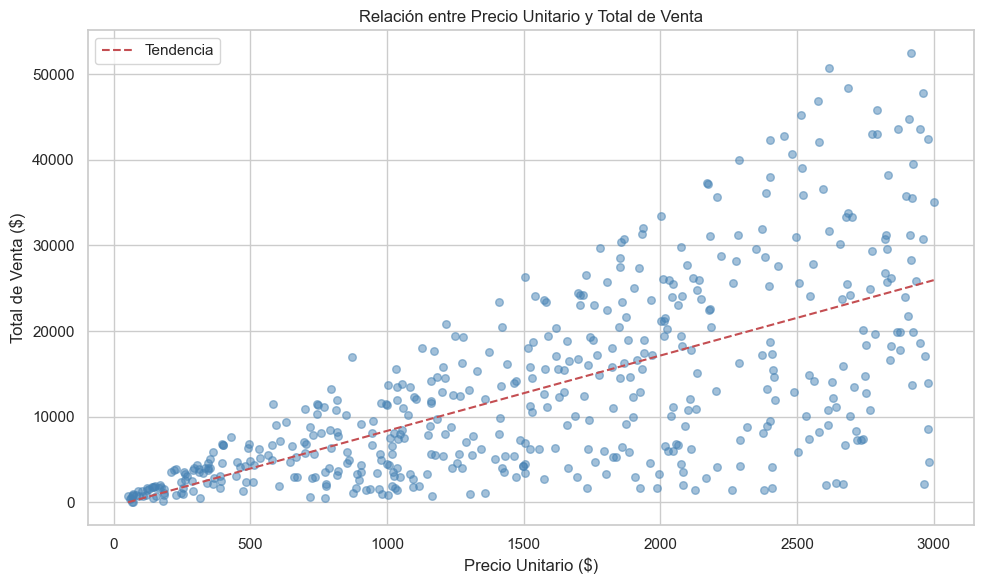

In [14]:

muestra = df.sample(n=500, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(muestra['precio_unitario'], muestra['total_venta'],
           alpha=0.5, color='steelblue', s=30)


z = np.polyfit(muestra['precio_unitario'], muestra['total_venta'], 1)
p = np.poly1d(z)
x_vals = np.linspace(muestra['precio_unitario'].min(),
                      muestra['precio_unitario'].max(), 100)
ax.plot(x_vals, p(x_vals), 'r--', label='Tendencia')

ax.set_title('Relación entre Precio Unitario y Total de Venta')
ax.set_xlabel('Precio Unitario ($)')
ax.set_ylabel('Total de Venta ($)')
ax.legend()

plt.tight_layout()
plt.savefig('scatter.png')
plt.show()

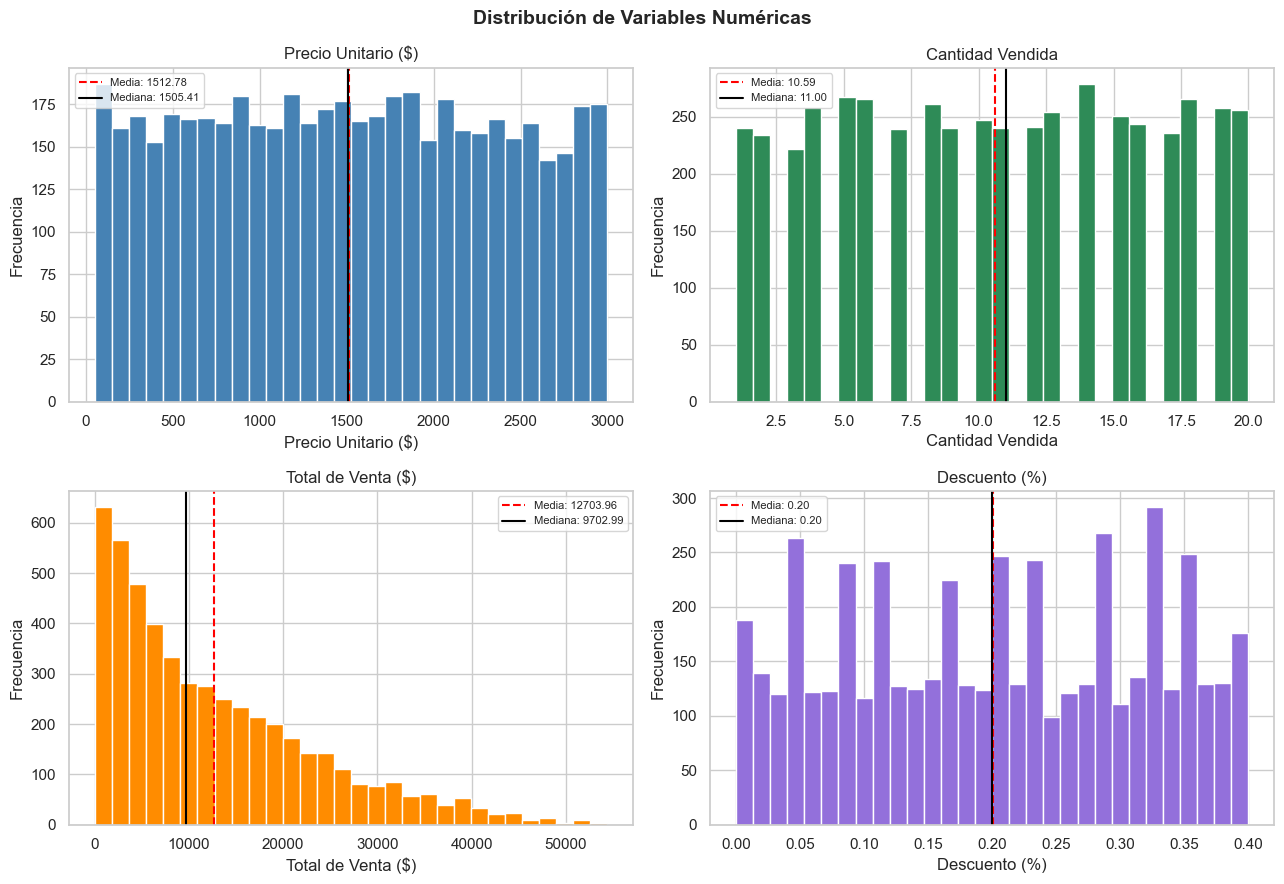

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

variables = [
    ('precio_unitario', 'Precio Unitario ($)', 'steelblue'),
    ('cantidad',        'Cantidad Vendida',    'seagreen'),
    ('total_venta',     'Total de Venta ($)',  'darkorange'),
    ('descuento_pct',   'Descuento (%)',       'mediumpurple'),
]

for ax, (col, titulo, color) in zip(axes.flat, variables):
    ax.hist(df[col], bins=30, color=color, edgecolor='white')

    # Líneas de media y mediana
    ax.axvline(df[col].mean(),   color='red',   linestyle='--',
               label=f'Media: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='black', linestyle='-',
               label=f'Mediana: {df[col].median():.2f}')

    ax.set_title(titulo)
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas.png')
plt.show()